In [4]:
import os                                                                                                                                                   
os.environ['HF_HOME'] = '/media/anna/Samsung_T5/hf_cache'

from transformers import RobertaForMaskedLM, BertForMaskedLM, AutoModel
import matplotlib.pyplot as plt
import numpy as np
import re

2026-04-27 23:12:18.902007: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
import huggingface_hub
print(huggingface_hub.constants.HF_HOME)                                                                                                                    
print(huggingface_hub.constants.HF_HUB_CACHE)


/media/anna/Samsung_T5/hf_cache
/media/anna/Samsung_T5/hf_cache/hub


In [6]:
def flatten_model(model, n_layers=12):
    """Extract and flatten encoder weight matrices by layer.
    Works for both BERT (bert.encoder.layer.N) and RoBERTa (roberta.encoder.layer.N) HF models.
    Excludes LayerNorm and bias weights.
    """
    params_by_layer = [[] for _ in range(n_layers)]
    for name, param in model.named_parameters():
        if 'encoder' not in name:
            continue
        if not name.endswith('weight'):
            continue
        if 'LayerNorm' in name or 'layer_norm' in name:
            continue
        m = re.search(r'encoder\.layer\.(\d+)\.', name)
        if not m:
            continue
        layer_num = int(m.group(1))
        param_np = param.detach().numpy()
        if param_np.ndim > 1:
            params_by_layer[layer_num].extend(param_np)
        else:
            params_by_layer[layer_num].append(param_np)
    return [[i for p in layer for i in p] for layer in params_by_layer]


def weight_hist(flattened_params, model_name, log=False, filter_high=False):
    cmap = plt.get_cmap('tab20')
    for idx, layer in enumerate(flattened_params):
        if filter_high:
            layer = [i for i in layer if abs(i) < 0.6]
        counts, edges = np.histogram(layer, bins=100)
        if log:
            counts = np.log10([i + 1 for i in counts])
        centers = (edges[:-1] + edges[1:]) / 2
        plt.plot(centers, counts, label=str(idx), color=cmap(idx))
    plt.title(model_name)
    plt.ylabel('Log10 Counts' if log else 'Counts')
    plt.xlabel('Weight Value')
    plt.legend(title='Layer')
    plt.savefig(f'{model_name}_wgt_dist.pdf')
    plt.show()

## Public baseline models

In [3]:
m_roberta_base = RobertaForMaskedLM.from_pretrained('roberta-base')
flat_roberta_base = flatten_model(m_roberta_base)
weight_hist(flat_roberta_base, 'RoBERTa-Base', log=True, filter_high=False)

NameError: name 'RobertaForMaskedLM' is not defined

In [2]:
import numpy as np
np.std(flat_roberta_base)

NameError: name 'flat_roberta_base' is not defined

In [5]:
# m_bert_base = BertForMaskedLM.from_pretrained('bert-base-uncased')
# flat_bert_base = flatten_model(m_bert_base)
# weight_hist(flat_bert_base, 'BERT-Base-Uncased', log=True, filter_high=True)

Some weights of RobertaModel were not initialized from the model checkpoint at /media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_init and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


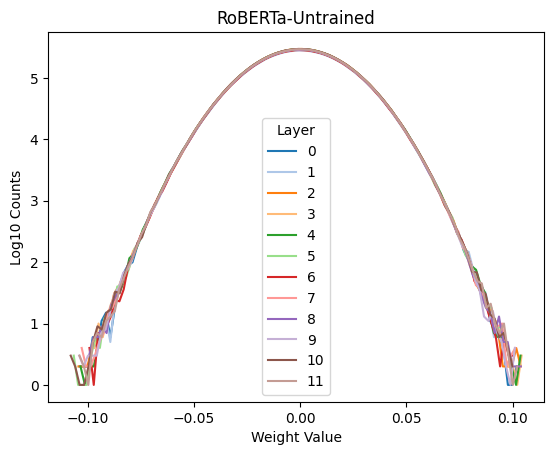

In [6]:
m_init = AutoModel.from_pretrained('/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_init')
flat_init = flatten_model(m_init)
weight_hist(flat_init, 'RoBERTa-Untrained', log=True, filter_high=False)

## Your trained models

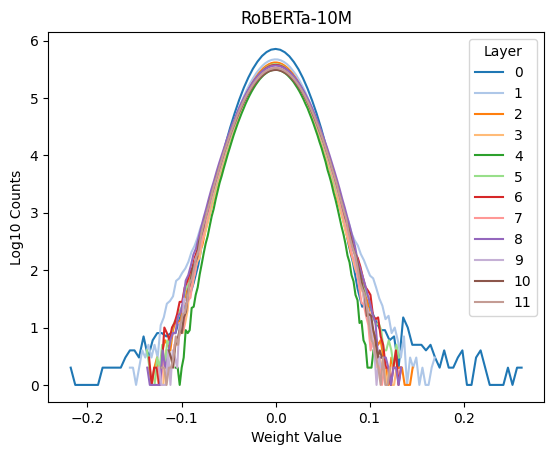

In [7]:
m_10M = RobertaForMaskedLM.from_pretrained('/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_10M/hf_20')
flat_10M = flatten_model(m_10M)
weight_hist(flat_10M, 'RoBERTa-10M', log=True, filter_high=False)

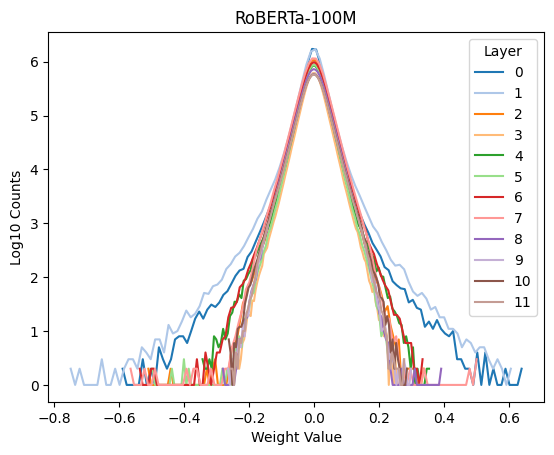

In [8]:
m_100M = RobertaForMaskedLM.from_pretrained('/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_100M/hf_20')
flat_100M = flatten_model(m_100M)
weight_hist(flat_100M, 'RoBERTa-100M', log=True, filter_high=False)

## Alajrami et al. models (aajrami on HuggingFace)

Despite being named `bert-*-base`, these are RoBERTa architecture (model_type: roberta).
They are released as base `RobertaModel` (no MLM head), so we use `AutoModel`.

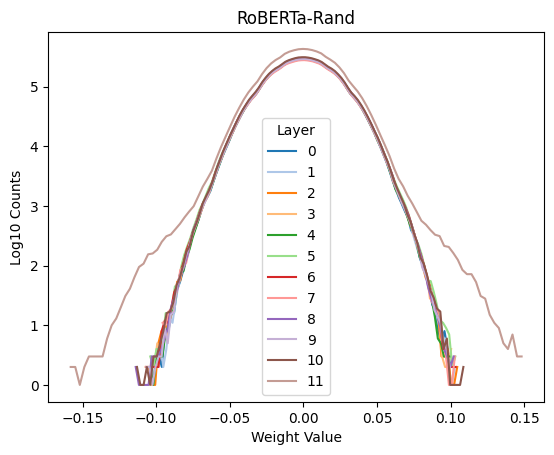

In [9]:
m_rand = AutoModel.from_pretrained('aajrami/bert-rand-base')
flat_rand = flatten_model(m_rand)
weight_hist(flat_rand, 'RoBERTa-Rand', log=True, filter_high=False)

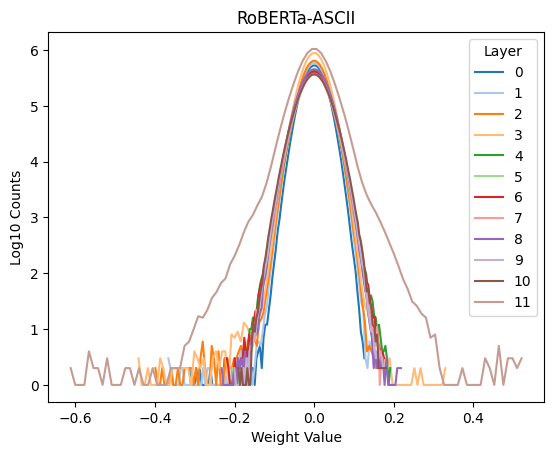

In [10]:
m_ascii = AutoModel.from_pretrained('aajrami/bert-ascii-base')
flat_ascii = flatten_model(m_ascii)
weight_hist(flat_ascii, 'RoBERTa-ASCII', log=True, filter_high=False)

## Fairseq shuffled word order model (Sinha et al.)

The `roberta.base.shuffle.n1` model from https://github.com/facebookresearch/fairseq/tree/main/examples/shuffled_word_order
is released as a fairseq checkpoint. The easiest path is to convert it to HuggingFace format first:

```bash
# 1. Download the checkpoint (see fairseq README for link)
# 2. Use downloaded conversion script to convert to pytorch

Alternatively, if fairseq is installed, load natively and use `flatten_model_fairseq` below.

Some weights of RobertaModel were not initialized from the model checkpoint at /media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_sent and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


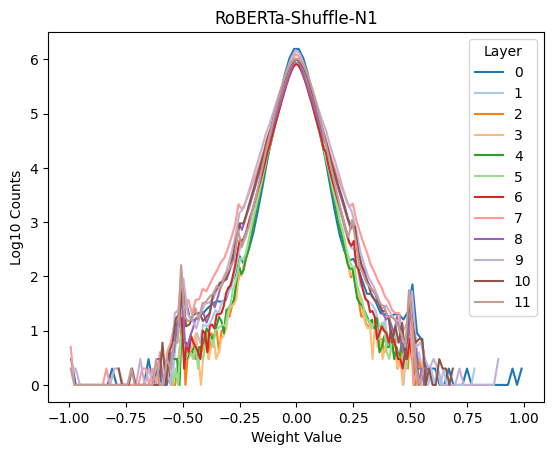

In [11]:
# Option A: HuggingFace-converted model (preferred)
# # Update path after converting the checkpoint
SHUFFLE_HF_PATH = '/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_sent'

m_shuffle = AutoModel.from_pretrained(SHUFFLE_HF_PATH)
flat_shuffle = flatten_model(m_shuffle)
weight_hist(flat_shuffle, 'RoBERTa-Shuffle-N1', log=True, filter_high=False)

Some weights of RobertaModel were not initialized from the model checkpoint at /media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_corpus and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


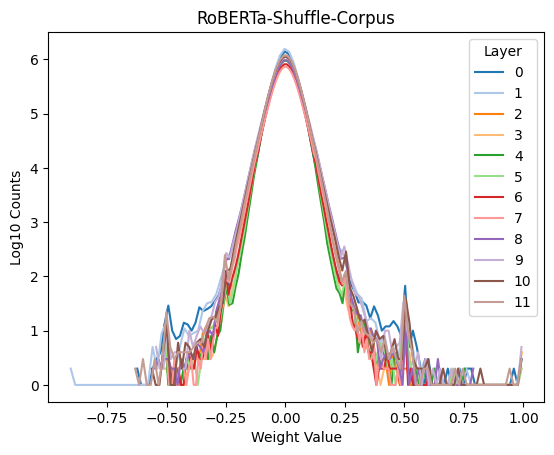

In [12]:
# Option A: HuggingFace-converted model (preferred)
# # Update path after converting the checkpoint
CORPUS_HF_PATH = '/media/anna/Samsung_T5/Initialization/HPC_store/models/roberta_corpus'

m_corpus = AutoModel.from_pretrained(CORPUS_HF_PATH)
flat_corpus = flatten_model(m_corpus)
weight_hist(flat_corpus, 'RoBERTa-Shuffle-Corpus', log=True, filter_high=False)

In [13]:
flat_corpus == flat_shuffle

False

In [14]:
# # Option B: Load natively with fairseq (if installed)
# # fairseq uses different parameter naming: sentence_encoder.layers.N.*

# def flatten_model_fairseq(roberta_hub_model, n_layers=12):
#     """Flatten encoder weights from a fairseq RoBERTa model loaded via torch.hub or fairseq API."""
#     params_by_layer = [[] for _ in range(n_layers)]
#     for name, param in roberta_hub_model.model.named_parameters():
#         if 'sentence_encoder.layers' not in name:
#             continue
#         if not name.endswith('weight'):
#             continue
#         if 'layer_norm' in name.lower() or 'embed' in name:
#             continue
#         m = re.search(r'layers\.(\d+)\.', name)
#         if not m:
#             continue
#         layer_num = int(m.group(1))
#         param_np = param.detach().numpy()
#         if param_np.ndim > 1:
#             params_by_layer[layer_num].extend(param_np)
#         else:
#             params_by_layer[layer_num].append(param_np)
#     return [[i for p in layer for i in p] for layer in params_by_layer]


# # import torch
# # m_shuffle_fs = torch.hub.load('pytorch/fairseq', 'roberta.base.shuffle.n1')
# # flat_shuffle_fs = flatten_model_fairseq(m_shuffle_fs)
# # weight_hist(flat_shuffle_fs, 'RoBERTa-Shuffle-N1 (Sinha et al.)', log=True, filter_high=True)